In [1]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

Torch version: 2.6.0+cu118
CUDA available: True
CUDA device name: NVIDIA GeForce GTX 1650 with Max-Q Design


In [2]:
import os
import pandas as pd

load_dir = r"C:\Users\olish\Documents\ml_projects\Steps_Predictor\model\data\clean\steps"

dfs = {}

for file_name in os.listdir(load_dir):
    if file_name.endswith(".pkl"):
        file_path = os.path.join(load_dir, file_name)
        
        df_name = file_name.replace(".pkl", "")
        dfs[df_name] = pd.read_pickle(file_path)

In [3]:
import numpy as np

data = dfs['oli']

data.tail()

,date,value
3640,2024-07-18,5479
3642,2024-07-19,8883
3644,2024-07-20,14678
3646,2024-07-21,8999
3648,2024-07-22,9725


In [4]:
data.describe()


,date,value
count,2072,2072.000000
mean,2021-09-19 12:44:28.725868800,8108.018822
min,2018-11-18 00:00:00,292.000000
25%,2020-04-18 18:00:00,5834.750000
50%,2021-09-20 12:00:00,7832.000000
75%,2023-02-20 06:00:00,9916.250000
max,2024-07-22 00:00:00,23919.000000
std,NaN,3387.438724


In [5]:
# "Wait, but how exactly is the user removing the quartile? Are they removing the lowest 25% of the entire dataset, 
# or within each time window? If it's the entire dataset, that might be altering the temporal sequence, which could be problematic. 
# But if it's done properly, ensuring that the time series isn't disrupted, then maybe it's acceptable."

In [6]:
# Calculate the 25th percentile
first_quartile = data['value'].quantile(0.25)

# Filter the dataframe to drop rows where 'value' is less than or equal to the first quartile
data = data[data['value'] > first_quartile]

data.reset_index(drop=True, inplace=True)
data.head()

,date,value
0,2018-11-19,8335
1,2018-11-20,6946
2,2018-11-21,8350
3,2018-11-22,11054
4,2018-11-23,10374


In [7]:
data["month"] = data.date.dt.month.astype(str).astype("category")
data["time_idx"] = (data["date"] - data["date"].min()).dt.days
data["log_value"] = np.log(data.value + 1e-8)
data.head()

C:\Users\olish\AppData\Local\Temp\ipykernel_2568\2081990685.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["month"] = data.date.dt.month.astype(str).astype("category")
C:\Users\olish\AppData\Local\Temp\ipykernel_2568\2081990685.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["time_idx"] = (data["date"] - data["date"].min()).dt.days
C:\Users\olish\AppData\Local\Temp\ipykernel_2568\2081990685.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
T

,date,value,month,time_idx,log_value
0,2018-11-19,8335,11,0,9.028219
1,2018-11-20,6946,11,1,8.845921
2,2018-11-21,8350,11,2,9.030017
3,2018-11-22,11054,11,3,9.310548
4,2018-11-23,10374,11,4,9.247058


In [8]:
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting import GroupNormalizer

data["value"] = data["value"].astype(float)
data["log_value"] = data["log_value"].astype(float)

data["group"] = 0

max_prediction_length = 1
max_encoder_length = 30
training_cutoff = data["time_idx"].max() - max_prediction_length

training = TimeSeriesDataSet(
    data[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="value",
    group_ids=["group"],
    min_encoder_length=max_encoder_length // 2,  
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    time_varying_known_categoricals=["month"],
    time_varying_known_reals=["time_idx"],
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=[
        "value",
        "log_value"],
     target_normalizer=GroupNormalizer(
         groups=["group"], transformation="softplus"
         ),     
     add_relative_time_idx=True,
     add_target_scales=True,
     add_encoder_length=True,
     allow_missing_timesteps=True
)

validation = TimeSeriesDataSet.from_dataset(training, data, predict=True, stop_randomization=True)

batch_size = 128
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0) #pin_memory=True) #, persistent_workers=True) #pin memory speeds up transfer to gpu
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=0) # persistent_workers=True)

c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\pytorch_forecasting\models\base_model.py:27: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
C:\Users\olish\AppData\Local\Temp\ipykernel_2568\1464381275.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["value"] = data["value"].astype(float)
C:\Users\olish\AppData\Local\Temp\ipykernel_2568\1464381275.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

In [9]:
from pytorch_forecasting import Baseline
from pytorch_forecasting.metrics import MAE

baseline_predictions = Baseline().predict(val_dataloader, return_y=True)
MAE()(baseline_predictions.output, baseline_predictions.y)

c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be

tensor(726., device='cuda:0')

In [10]:
import lightning.pytorch as pl
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss
from ranger_adabelief import RangerAdaBelief

pl.seed_everything(42)
trainer = pl.Trainer(
    accelerator="gpu",
    devices=1,
    # clipping gradients is a hyperparameter and important to prevent divergance
    # of the gradient for recurrent neural networks
    gradient_clip_val=0.1,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    # not meaningful for finding the learning rate but otherwise very important
    learning_rate=0.03,
    hidden_size=8,  # most important hyperparameter apart from learning rate
    # number of attention heads. Set to up to 4 for large datasets
    attention_head_size=1,
    dropout=0.1,  # between 0.1 and 0.3 are good values
    hidden_continuous_size=8,  # set to <= hidden_size
    loss=QuantileLoss(),
    # reduce learning rate if no improvement in validation loss after x epochs
    # reduce_on_plateau_patience=1000,
)

optimizer = RangerAdaBelief(tft.parameters(), lr=1e-3)

print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


Ranger optimizer loaded. 
Gradient Centralization usage = True
GC applied to both conv and fc layers
Number of parameters in network: 7.5k


c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\lightning\pytorch\loops\utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (14) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
c:\Users\olish\Documents\ml_projects\Steps_Predictor\mode

suggested learning rate: 0.013489628825916528


C:\Users\olish\AppData\Local\Temp\ipykernel_2568\535354460.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


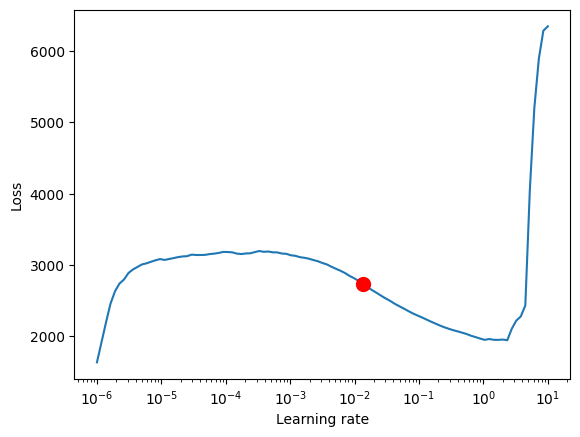

In [11]:
# find optimal learning rate
from lightning.pytorch.tuner import Tuner
from lightning.pytorch import loggers

lr_logger = loggers.TensorBoardLogger(save_dir="/logger", name="lr")

res = Tuner(trainer).lr_find(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    max_lr=10.0,
    min_lr=1e-6,
)

print(f"suggested learning rate: {res.suggestion()}")

# Get the plot data
fig = res.plot(show=False, suggest=True)
fig.show()

In [12]:
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

# configure network and trainer
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min")
lr_logger = LearningRateMonitor()  # log the learning rate
logger = TensorBoardLogger("lightning_logs", name="tft_v1")  # logging results to a tensorboard #param to name and save model: name=tft_v0

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="gpu",
    devices=1,
    #strategy="ddp", for devviding workload to processing units.  Only works in a script
    enable_model_summary=True,
    gradient_clip_val=0.1,
    limit_train_batches=50,  # coment in for training, running valiation every 30 batches
    # fast_dev_run=True,  # comment in to check that networkor dataset has no serious bugs
    callbacks=[lr_logger, early_stop_callback],
    logger=logger,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.005,
    hidden_size=16,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss(),
    log_interval=10,  # uncomment for learning rate finder and otherwise, e.g. to 10 for logging every 10 batches
    # optimizer="Ranger",
    reduce_on_plateau_patience=4,
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Number of parameters in network: 19.6k


c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


CHANGES WERE MADE TO THE BELOW CLASS TO RESOLVE YERR ERROR.  THIS IS BAD. BASE MODEL NEEDS TO BE SUBCLASSED: 
C:\Users\olish\Documents\ml_projects\Steps_Predictor\model\venv\Lib\site-packages\pytorch_forecasting\models\base_model.py
    - Line 1258 was commented out and 1259 was inserted.  

YERR ERROR SOLUTION REFERENCE:
https://github.com/sktime/pytorch-forecasting/pull/1579/files

In [13]:
# fit network
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 72     | train
3  | prescalers                         | ModuleDict                      | 112    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 1.7 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 2.6 K  | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 1.3 K  | train
7  | static_context_variable_selection  | GatedResidualNetwork            | 1.1 K  | train
8  | static_context_initial_hidden_lstm |

Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (14) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 13: 100%|██████████| 14/14 [00:06<00:00,  2.20it/s, v_num=12, train_loss_step=1.13e+3, val_loss=601.0, train_loss_epoch=1.02e+3]


In [14]:
print(f"Number of GPUs available: {torch.cuda.device_count()}")

Number of GPUs available: 1


In [15]:
import pickle


from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
import torch

accelerator = "gpu" 
devices = 1 
# create study
study = optimize_hyperparameters(
    train_dataloader,
    val_dataloader,
    model_path="optuna_test",
    n_trials=200,
    max_epochs=50,
    gradient_clip_val_range=(0.01, 1.0),
    hidden_size_range=(8, 128),
    hidden_continuous_size_range=(8, 128),
    attention_head_size_range=(1, 4),
    learning_rate_range=(0.001, 0.1),
    dropout_range=(0.1, 0.3),
    trainer_kwargs=dict(
        limit_train_batches=30,
        accelerator=accelerator,  # Enable GPU if available
        devices=devices,
    ),
    reduce_on_plateau_patience=4,
    use_learning_rate_finder=False,  # use Optuna to find ideal learning rate or use in-built learning rate finder
)

# save study results - also we can resume tuning at a later point in time
with open("test_study.pkl", "wb") as fout:
    pickle.dump(study, fout)

# show best hyperparameters
print(study.best_trial.params)

[I 2025-02-11 10:36:57,075] A new study created in memory with name: no-name-d9b79b27-6eb3-4426-b90d-4fbc413522d7
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\pytorch_forecasting\models\temporal_fusion_transformer\tuning.py:142: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  gradient_clip_val = trial.suggest_loguniform(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\pytorch_forecasting\models\temporal_fusion_transformer\tuning.py:168: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout=trial.su

{'gradient_clip_val': 0.24713439869174628, 'hidden_size': 23, 'dropout': 0.27273560428074584, 'hidden_continuous_size': 9, 'attention_head_size': 4, 'learning_rate': 0.025528605692489024}


In [16]:
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [17]:
predictions = best_tft.predict(val_dataloader, return_y=True, trainer_kwargs=dict(accelerator="cpu"))
mae = MAE()(predictions.output, predictions.y)
print(f'Mean Absolute Error: {mae}')

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Mean Absolute Error: 964.4326171875


c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\lightning\pytorch\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


In [18]:
raw_predictions = best_tft.predict(val_dataloader, mode="raw", return_x=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Encoder target size: torch.Size([1, 28])
Decoder target size: torch.Size([1, 1])
Index: 0


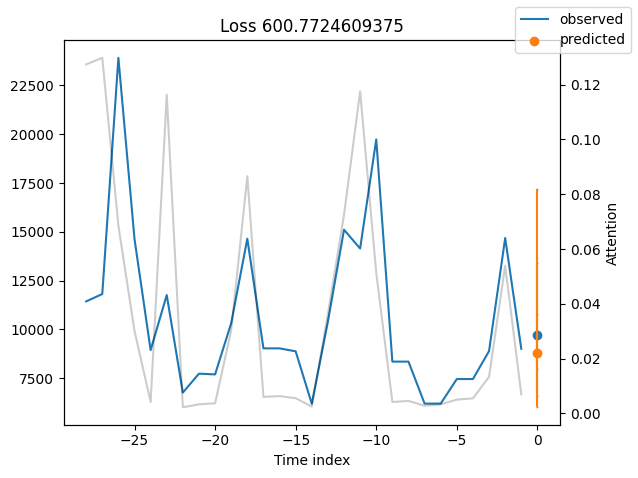

In [19]:
encoder_target = raw_predictions.x["encoder_target"]
decoder_target = raw_predictions.x["decoder_target"]

for idx in range(encoder_target.size(0)):  
    print(f"Encoder target size: {encoder_target.size()}")
    print(f"Decoder target size: {decoder_target.size()}")
    print(f"Index: {idx}")
    
    best_tft.plot_prediction(
        raw_predictions.x, 
        raw_predictions.output, 
        idx=idx, 
        add_loss_to_title=True
    )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


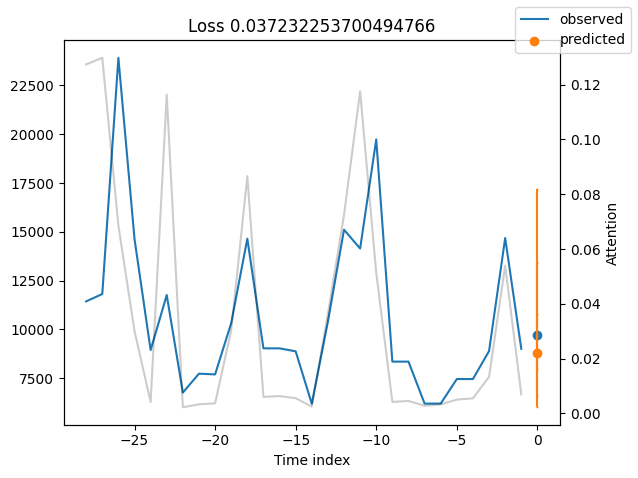

In [20]:
from pytorch_forecasting.metrics import SMAPE

predictions = best_tft.predict(val_dataloader, return_y=True)
mean_losses = SMAPE(reduction="none").loss(predictions.output, predictions.y[0]).mean(1)
indices = mean_losses.argsort(descending=True)  
for idx in range(encoder_target.size(0)):  
    best_tft.plot_prediction(
        raw_predictions.x,
        raw_predictions.output,
        idx=indices[idx],
        add_loss_to_title=SMAPE(quantiles=best_tft.loss.quantiles),
    )

In [21]:
print(f"Batch size: {raw_predictions.x['encoder_target'].size(0)}")

Batch size: 1


In [22]:
print(raw_predictions.x)

{'encoder_cat': tensor([[[8],
         [8],
         [8],
         [8],
         [8],
         [8],
         [8],
         [9],
         [9],
         [9],
         [9],
         [9],
         [9],
         [9],
         [9],
         [9],
         [9],
         [9],
         [9],
         [9],
         [9],
         [9],
         [9],
         [9],
         [9],
         [9],
         [9],
         [9]]], device='cuda:0'), 'encoder_cont': tensor([[[ 8.6667e-01,  1.8190e-12, -9.0949e-13,  1.6660e+00, -9.3333e-01,
           7.1530e-01,  8.5799e-01],
         [ 8.6667e-01,  1.8190e-12, -9.0949e-13,  1.6676e+00, -9.0000e-01,
           8.4922e-01,  9.7779e-01],
         [ 8.6667e-01,  1.8190e-12, -9.0949e-13,  1.6693e+00, -8.6667e-01,
           5.1635e+00,  3.5911e+00],
         [ 8.6667e-01,  1.8190e-12, -9.0949e-13,  1.6710e+00, -8.3333e-01,
           1.8543e+00,  1.7711e+00],
         [ 8.6667e-01,  1.8190e-12, -9.0949e-13,  1.6726e+00, -8.0000e-01,
          -1.7334e-01, -5.3495e-0

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\gpu_venv\Lib\site-packages\pytorch_forecasting\models\base_model.py:2092: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1831.)
  skew = torch.mean(((y_flat - torch.mean(y_flat)) / torch.std(y_flat)) ** 3)


{'encoder_length': <Figure size 1000x500 with 2 Axes>,
 'value_center': <Figure size 1000x500 with 2 Axes>,
 'value_scale': <Figure size 1000x500 with 2 Axes>,
 'time_idx': <Figure size 1000x500 with 2 Axes>,
 'relative_time_idx': <Figure size 1000x500 with 2 Axes>,
 'value': <Figure size 1000x500 with 2 Axes>,
 'log_value': <Figure size 1000x500 with 2 Axes>,
 'month': <Figure size 1000x500 with 2 Axes>}

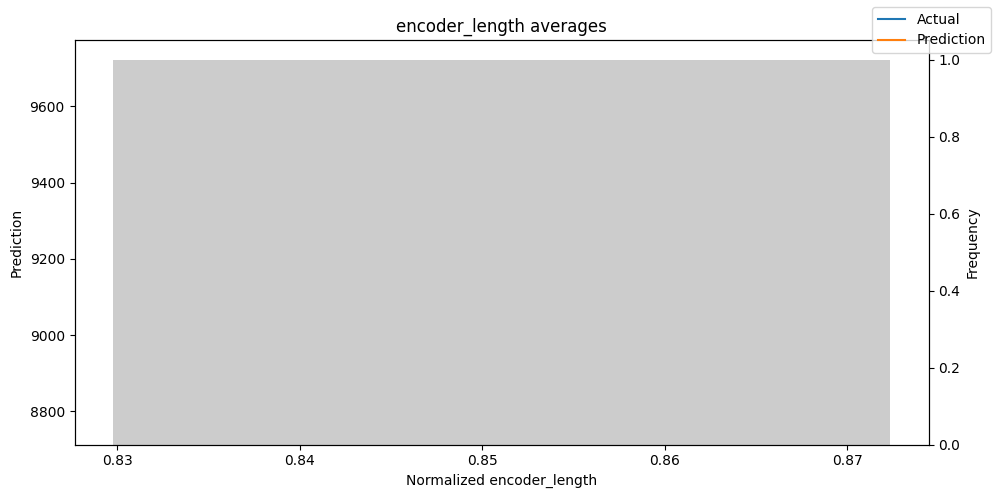

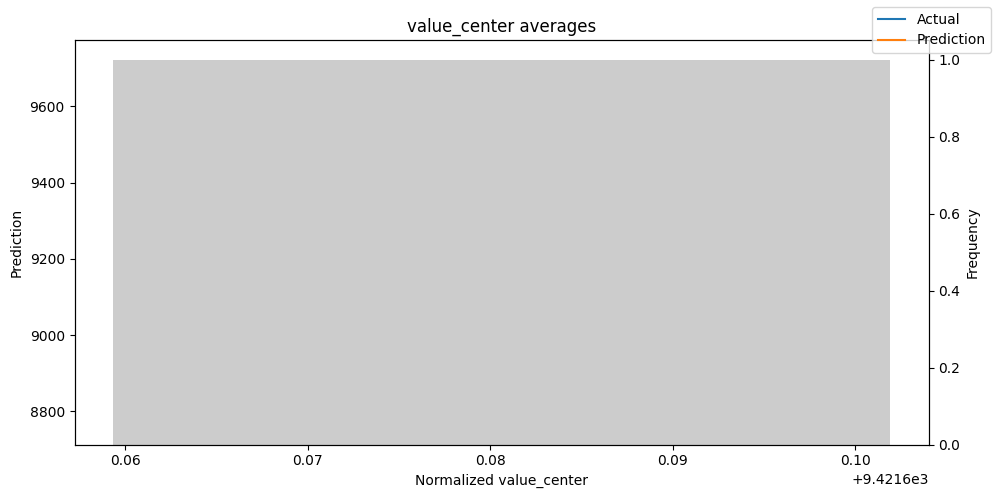

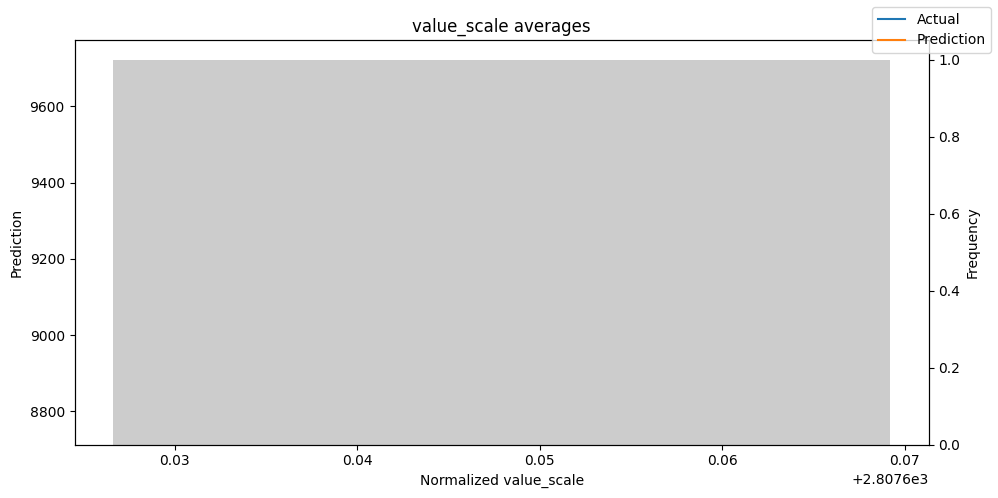

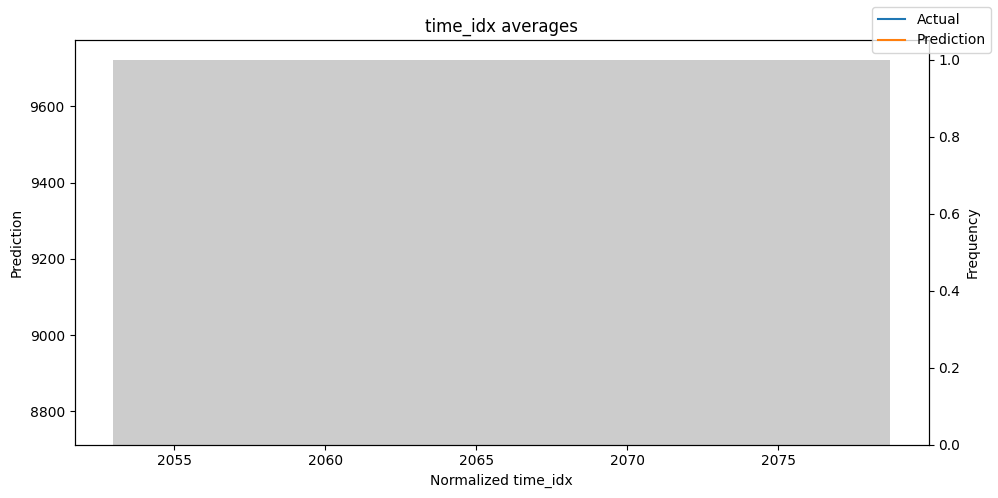

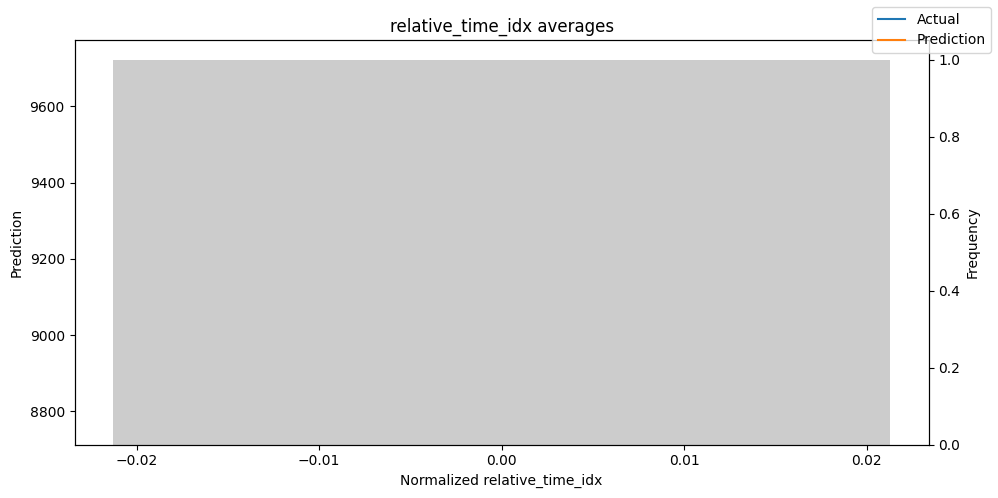

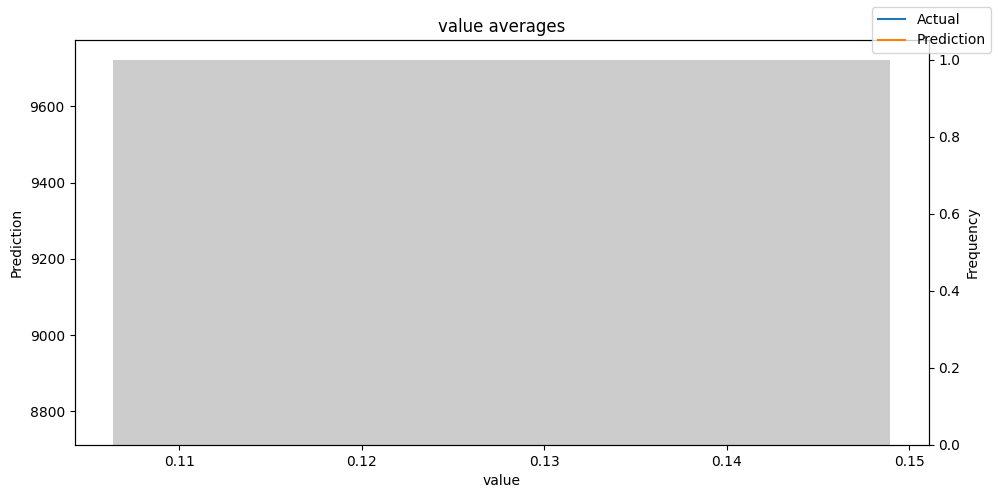

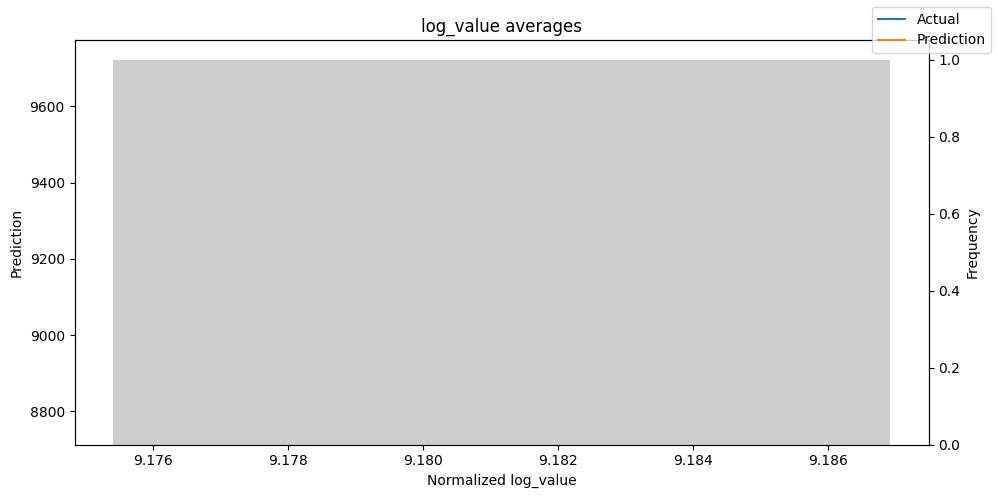

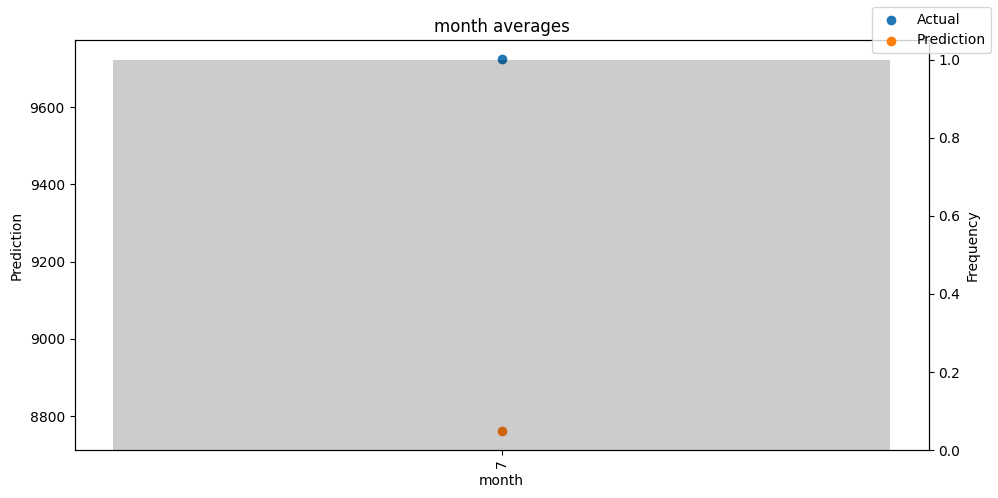

In [23]:
predictions = best_tft.predict(val_dataloader, return_x=True)
predictions_vs_actuals = best_tft.calculate_prediction_actual_by_variable(predictions.x, predictions.output)
best_tft.plot_prediction_actual_by_variable(predictions_vs_actuals)

In [24]:
print(predictions_vs_actuals)

{'support': {'encoder_length': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       device='cuda:0'), 'value_center': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       device='cuda:0'), 'value_scale': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0

In [25]:
best_tft.predict(
    training.filter(lambda x: x.time_idx_first_prediction == 15),
    mode="quantiles",
)

ValueError: After applying filter no sub-sequences left in dataset

In [ ]:
raw_prediction = best_tft.predict(
    training.filter(lambda x: x.time_idx_first_prediction == 2000),
    mode="raw",
    return_x=True,
)
best_tft.plot_prediction(raw_prediction.x, raw_prediction.output, idx=0)

ValueError: After applying filter no sub-sequences left in dataset